In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier

In [4]:
train = pd.read_csv("train.csv")
public = pd.read_csv("public_test.csv")
private = pd.read_csv("private_test.csv")

In [5]:
train.head()

,User_ID,Age,Income,City_Tier,Device_Type,Traffic_Source,Pages_Viewed,Products_Viewed,Time_On_Site,Previous_Purchases,Discount_Seen,Browser_Version,Campaign_Code,Converted
0,1,58.0,103593.708812,2,Mobile,Organic,5,4,9.61,3,0,11,2418,0
1,2,26.0,36451.716984,2,Mobile,Social Media,11,3,17.63,2,0,14,1213,0
2,3,19.0,30511.228700,3,Mobile,Referral,1,1,13.25,5,0,5,2849,0
3,4,48.0,87789.172342,3,Mobile,Email,14,12,NaN,1,1,19,7610,0
4,5,35.0,105229.249067,2,Mobile,Social Media,14,21,16.92,1,0,5,9261,0


In [6]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   User_ID             10000 non-null  int64  
 1   Age                 8520 non-null   float64
 2   Income              9016 non-null   float64
 3   City_Tier           10000 non-null  int64  
 4   Device_Type         10000 non-null  str    
 5   Traffic_Source      10000 non-null  str    
 6   Pages_Viewed        10000 non-null  int64  
 7   Products_Viewed     10000 non-null  int64  
 8   Time_On_Site        8152 non-null   float64
 9   Previous_Purchases  10000 non-null  int64  
 10  Discount_Seen       10000 non-null  int64  
 11  Browser_Version     10000 non-null  int64  
 12  Campaign_Code       10000 non-null  int64  
 13  Converted           10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
memory usage: 1.1 MB


In [7]:
train.describe()

,User_ID,Age,Income,City_Tier,Pages_Viewed,Products_Viewed,Time_On_Site,Previous_Purchases,Discount_Seen,Browser_Version,Campaign_Code,Converted
count,10000.00000,8520.000000,9016.000000,10000.000000,10000.00000,10000.000000,8152.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,41.457746,69961.772797,1.933400,15.60850,15.219300,13.667241,2.972500,0.540700,12.473900,5511.162200,0.30870
std,2886.89568,13.770164,24790.673822,0.737712,8.62346,8.927563,19.438244,1.738691,0.498366,6.892856,2596.933802,0.46198
min,1.00000,18.000000,12000.000000,1.000000,1.00000,1.000000,0.800000,0.000000,0.000000,1.000000,1000.000000,0.00000
25%,2500.75000,29.000000,52294.644359,1.000000,8.00000,8.000000,7.640000,2.000000,0.000000,7.000000,3251.750000,0.00000
50%,5000.50000,41.000000,70171.613672,2.000000,16.00000,15.000000,11.145000,3.000000,1.000000,12.000000,5515.500000,0.00000
75%,7500.25000,53.000000,86907.747154,2.000000,23.00000,23.000000,15.630000,4.000000,1.000000,18.000000,7759.000000,1.00000
max,10000.00000,65.000000,161687.774167,3.000000,30.00000,37.000000,607.390000,12.000000,1.000000,24.000000,9998.000000,1.00000


In [8]:
train.isnull().sum()

User_ID                  0
Age                   1480
Income                 984
City_Tier                0
Device_Type              0
Traffic_Source           0
Pages_Viewed             0
Products_Viewed          0
Time_On_Site          1848
Previous_Purchases       0
Discount_Seen            0
Browser_Version          0
Campaign_Code            0
Converted                0
dtype: int64

In [9]:
public.head()

,User_ID,Age,Income,City_Tier,Device_Type,Traffic_Source,Pages_Viewed,Products_Viewed,Time_On_Site,Previous_Purchases,Discount_Seen,Browser_Version,Campaign_Code,Converted
0,100001,50.0,65922.413596,3,Tablet,Organic,15,16,NaN,2,0,13,5698,1
1,100002,39.0,43205.865640,1,Mobile,Paid Ads,17,16,12.72,2,1,10,7011,0
2,100003,NaN,44333.908253,3,Mobile,Organic,17,15,3.13,5,0,21,8265,1
3,100004,22.0,141906.816221,3,Desktop,Social Media,1,2,25.32,3,0,9,5592,0
4,100005,47.0,39521.673456,1,Mobile,Social Media,2,4,NaN,3,1,9,4128,0


In [10]:
public.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   User_ID             3000 non-null   int64  
 1   Age                 2528 non-null   float64
 2   Income              2699 non-null   float64
 3   City_Tier           3000 non-null   int64  
 4   Device_Type         3000 non-null   str    
 5   Traffic_Source      3000 non-null   str    
 6   Pages_Viewed        3000 non-null   int64  
 7   Products_Viewed     3000 non-null   int64  
 8   Time_On_Site        2432 non-null   float64
 9   Previous_Purchases  3000 non-null   int64  
 10  Discount_Seen       3000 non-null   int64  
 11  Browser_Version     3000 non-null   int64  
 12  Campaign_Code       3000 non-null   int64  
 13  Converted           3000 non-null   int64  
dtypes: float64(3), int64(9), str(2)
memory usage: 328.3 KB


In [11]:
public.describe()

,User_ID,Age,Income,City_Tier,Pages_Viewed,Products_Viewed,Time_On_Site,Previous_Purchases,Discount_Seen,Browser_Version,Campaign_Code,Converted
count,3000.000000,2528.000000,2699.000000,3000.000000,3000.000000,3000.000000,2432.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,101500.500000,41.660997,71103.390196,1.939333,15.378333,15.028000,13.780859,3.036000,0.550333,12.636333,5504.309333,0.295333
std,866.169729,14.030755,24469.813897,0.755321,8.708682,9.045873,21.283364,1.723667,0.497543,6.973351,2568.659082,0.456269
min,100001.000000,18.000000,12000.000000,1.000000,1.000000,1.000000,0.590000,0.000000,0.000000,1.000000,1003.000000,0.000000
25%,100750.750000,29.000000,53953.872038,1.000000,8.000000,7.000000,7.627500,2.000000,0.000000,7.000000,3299.250000,0.000000
50%,101500.500000,42.000000,70947.845512,2.000000,15.000000,15.000000,11.130000,3.000000,1.000000,13.000000,5493.000000,0.000000
75%,102250.250000,54.000000,88276.370022,3.000000,23.000000,23.000000,15.752500,4.000000,1.000000,19.000000,7675.250000,1.000000
max,103000.000000,65.000000,145218.173839,3.000000,30.000000,37.000000,431.100000,10.000000,1.000000,24.000000,9997.000000,1.000000


In [12]:
public.isnull().sum()

User_ID                 0
Age                   472
Income                301
City_Tier               0
Device_Type             0
Traffic_Source          0
Pages_Viewed            0
Products_Viewed         0
Time_On_Site          568
Previous_Purchases      0
Discount_Seen           0
Browser_Version         0
Campaign_Code           0
Converted               0
dtype: int64

In [13]:
private.head()

,User_ID,Age,Income,City_Tier,Device_Type,Traffic_Source,Pages_Viewed,Products_Viewed,Time_On_Site,Previous_Purchases,Discount_Seen,Browser_Version,Campaign_Code
0,103001,54.0,12000.000000,2,Mobile,Email,3,1,13.14,3,0,9,3685
1,103002,59.0,NaN,3,Mobile,Organic,22,20,NaN,4,0,18,9612
2,103003,NaN,79296.908337,2,Mobile,Paid Ads,28,24,3.36,1,0,2,4522
3,103004,19.0,65279.025663,2,Mobile,Social Media,20,13,8.78,6,1,5,4623
4,103005,31.0,NaN,3,Mobile,Paid Ads,10,15,24.14,5,0,20,8663


In [14]:
private.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   User_ID             3000 non-null   int64  
 1   Age                 2539 non-null   float64
 2   Income              2698 non-null   float64
 3   City_Tier           3000 non-null   int64  
 4   Device_Type         3000 non-null   str    
 5   Traffic_Source      3000 non-null   str    
 6   Pages_Viewed        3000 non-null   int64  
 7   Products_Viewed     3000 non-null   int64  
 8   Time_On_Site        2438 non-null   float64
 9   Previous_Purchases  3000 non-null   int64  
 10  Discount_Seen       3000 non-null   int64  
 11  Browser_Version     3000 non-null   int64  
 12  Campaign_Code       3000 non-null   int64  
dtypes: float64(3), int64(8), str(2)
memory usage: 304.8 KB


In [15]:
private.describe()

,User_ID,Age,Income,City_Tier,Pages_Viewed,Products_Viewed,Time_On_Site,Previous_Purchases,Discount_Seen,Browser_Version,Campaign_Code
count,3000.000000,2539.000000,2698.000000,3000.00000,3000.000000,3000.000000,2438.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,104500.500000,41.282001,70249.499155,1.95600,15.428667,15.008000,13.932974,2.959333,0.546333,12.341333,5519.437667
std,866.169729,13.687726,24802.551359,0.73773,8.708857,8.963856,22.061855,1.711721,0.497932,6.879966,2607.466173
min,103001.000000,18.000000,12000.000000,1.00000,1.000000,1.000000,0.380000,0.000000,0.000000,1.000000,1006.000000
25%,103750.750000,30.000000,53053.114312,1.00000,8.000000,7.000000,7.570000,2.000000,0.000000,6.000000,3245.500000
50%,104500.500000,42.000000,70465.721888,2.00000,15.000000,15.000000,10.880000,3.000000,1.000000,12.000000,5539.000000
75%,105250.250000,53.000000,87367.487425,3.00000,23.000000,22.250000,15.087500,4.000000,1.000000,18.000000,7711.250000
max,106000.000000,65.000000,181292.643570,3.00000,30.000000,37.000000,363.570000,10.000000,1.000000,24.000000,9995.000000


In [16]:
private.isnull().sum()

User_ID                 0
Age                   461
Income                302
City_Tier               0
Device_Type             0
Traffic_Source          0
Pages_Viewed            0
Products_Viewed         0
Time_On_Site          562
Previous_Purchases      0
Discount_Seen           0
Browser_Version         0
Campaign_Code           0
dtype: int64

In [17]:
missing = train.isnull().sum()

In [18]:
missing = pd.DataFrame({'Missing values' : missing, 'Percentage' : (missing/len(train))*100})

In [19]:
missing.sort_values(by = 'Percentage', ascending = False)

,Missing values,Percentage
Time_On_Site,1848,18.48
Age,1480,14.80
Income,984,9.84
User_ID,0,0.00
Device_Type,0,0.00
City_Tier,0,0.00
Traffic_Source,0,0.00
Pages_Viewed,0,0.00
Products_Viewed,0,0.00
Previous_Purchases,0,0.00


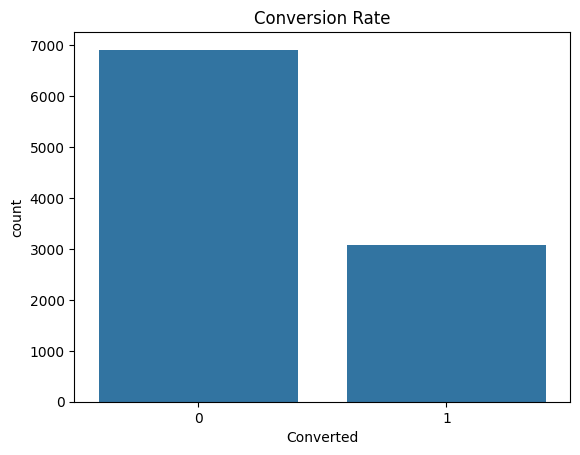

In [20]:
sns.countplot(x = 'Converted', data = train)

plt.title('Conversion Rate')
plt.show()

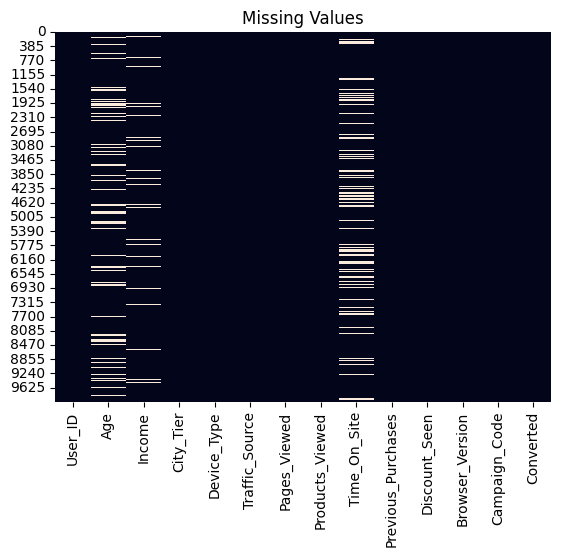

In [21]:
sns.heatmap(train.isnull(), cbar = False)

plt.title('Missing Values')
plt.show()

# What have we done till now:
#### --> Imported the required python libraries
#### --> Used some functions to know about the data
#### --> Found the missing values
#### --> Created some plots and graphs on them

In [22]:
numerical_cols = ['Age', 'Income', 'Pages_Viewed', 'Products_Viewed', 'Time_On_Site', 'Previous_Purchases']

train[numerical_cols].describe()

,Age,Income,Pages_Viewed,Products_Viewed,Time_On_Site,Previous_Purchases
count,8520.000000,9016.000000,10000.00000,10000.000000,8152.000000,10000.000000
mean,41.457746,69961.772797,15.60850,15.219300,13.667241,2.972500
std,13.770164,24790.673822,8.62346,8.927563,19.438244,1.738691
min,18.000000,12000.000000,1.00000,1.000000,0.800000,0.000000
25%,29.000000,52294.644359,8.00000,8.000000,7.640000,2.000000
50%,41.000000,70171.613672,16.00000,15.000000,11.145000,3.000000
75%,53.000000,86907.747154,23.00000,23.000000,15.630000,4.000000
max,65.000000,161687.774167,30.00000,37.000000,607.390000,12.000000


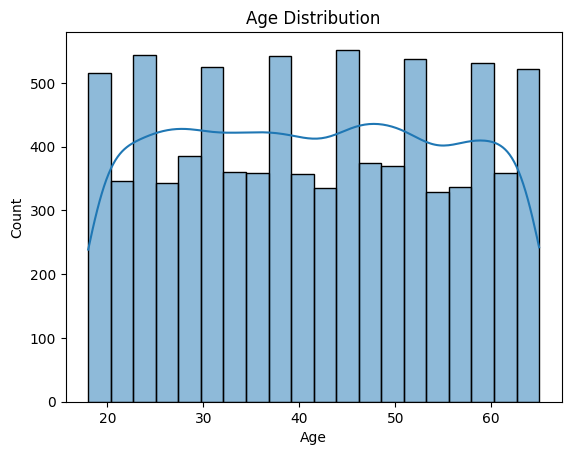

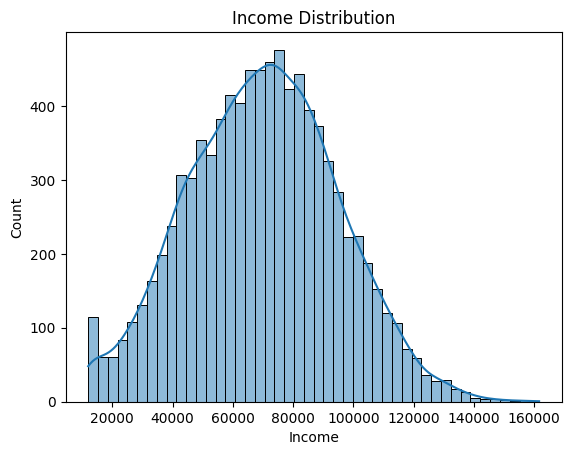

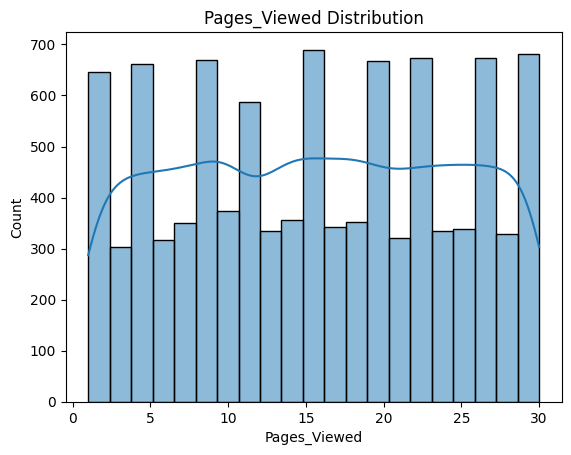

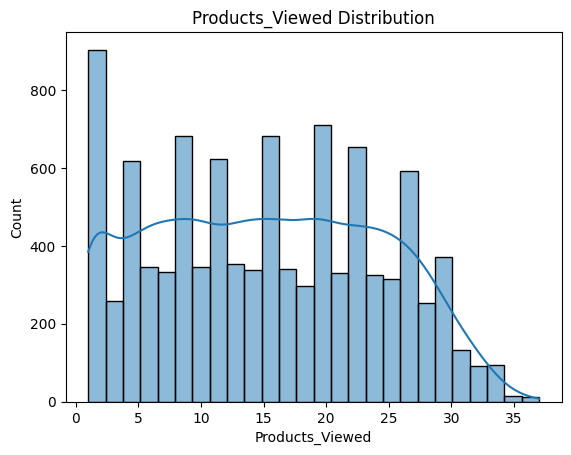

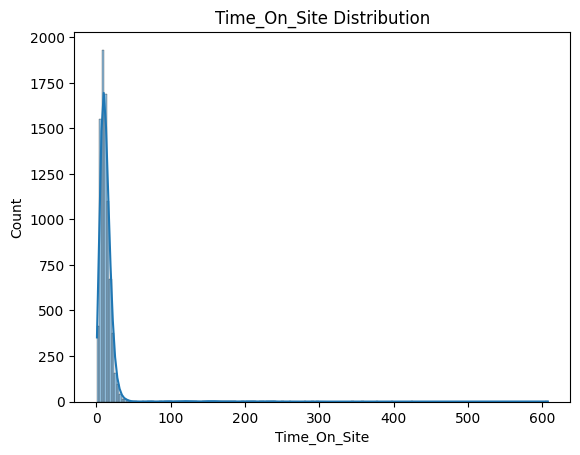

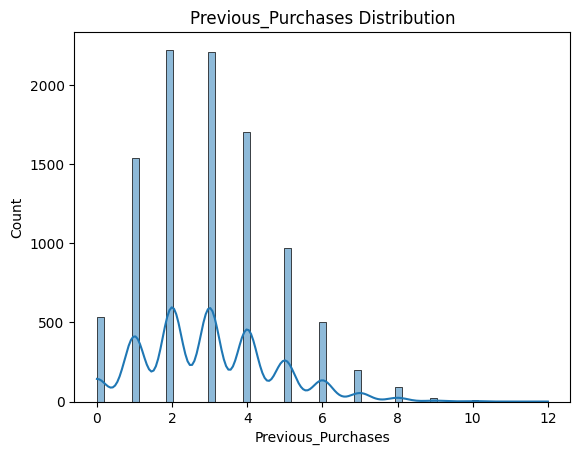

In [23]:
for col in numerical_cols:
    sns.histplot(train[col], kde = True)
    
    plt.title(f"{col} Distribution")

    plt.show()

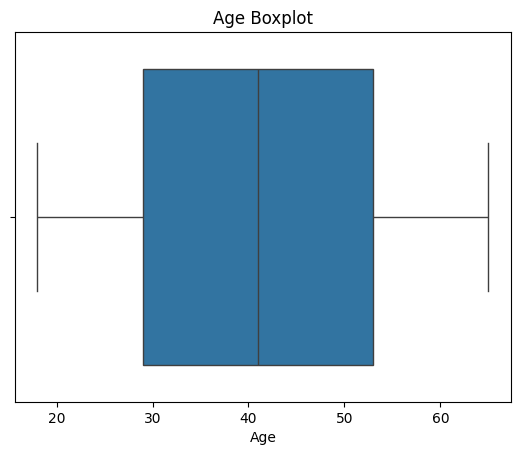

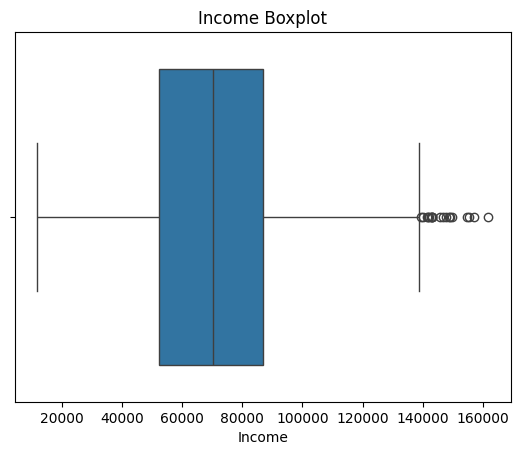

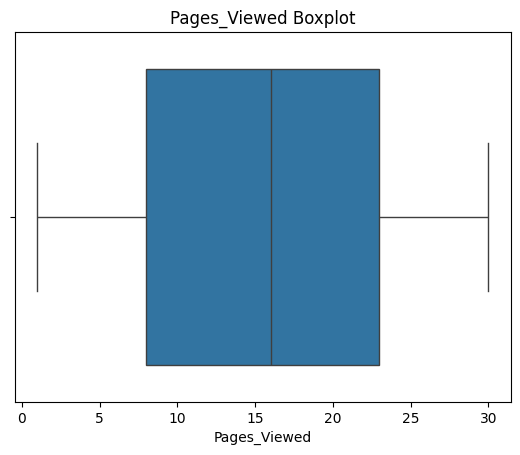

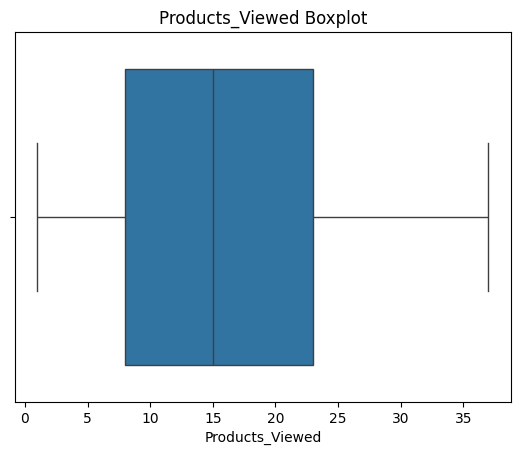

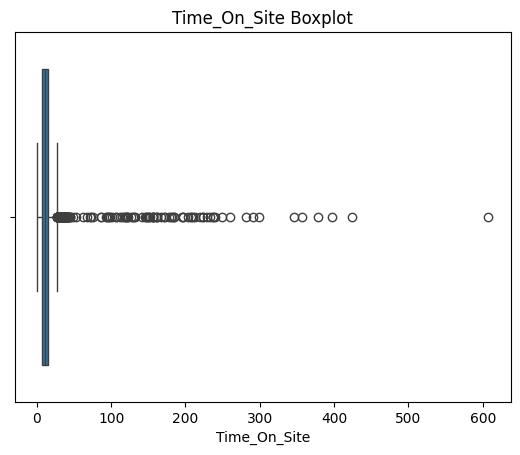

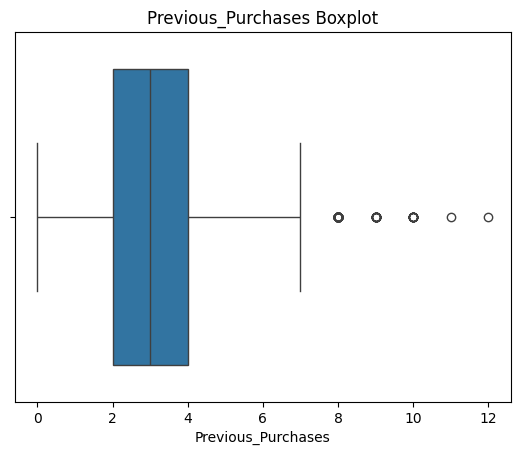

In [24]:
for col in numerical_cols:
    
    sns.boxplot(x = train[col])

    plt.title(f"{col} Boxplot")

    plt.show()

In [25]:
categorical_cols = ['City_Tier', 'Device_Type', 'Traffic_Source', 'Browser_Version', 'Campaign_Code', 'Discount_Seen']

categorical_cols

['City_Tier',
 'Device_Type',
 'Traffic_Source',
 'Browser_Version',
 'Campaign_Code',
 'Discount_Seen']

In [26]:
for col in categorical_cols:  
    print(f'Column: {col}')
    print(f'Unique Values: {train[col].nunique()}')

    print(train[col].unique(), '\n')


Column: City_Tier
Unique Values: 3
[2 3 1] 

Column: Device_Type
Unique Values: 3
<StringArray>
['Mobile', 'Desktop', 'Tablet']
Length: 3, dtype: str 

Column: Traffic_Source
Unique Values: 5
<StringArray>
['Organic', 'Social Media', 'Referral', 'Email', 'Paid Ads']
Length: 5, dtype: str 

Column: Browser_Version
Unique Values: 24
[11 14  5 19 16 23 20  4  7 24 10  2  6 18 22  9 15 21  8 12 17 13  1  3] 

Column: Campaign_Code
Unique Values: 6014
[2418 1213 2849 ... 8491 9175 7941] 

Column: Discount_Seen
Unique Values: 2
[0 1] 



In [27]:
for col in categorical_cols:
    print(train[col].value_counts(), '\n')

City_Tier
2    4514
1    3076
3    2410
Name: count, dtype: int64 

Device_Type
Mobile     6523
Desktop    2472
Tablet     1005
Name: count, dtype: int64 

Traffic_Source
Organic         3071
Paid Ads        2544
Social Media    1993
Referral        1456
Email            936
Name: count, dtype: int64 

Browser_Version
12    488
4     469
10    447
6     443
20    436
2     431
22    425
7     423
8     416
3     416
14    415
24    414
18    414
19    413
16    413
13    413
23    406
9     404
15    401
11    395
21    395
17    388
1     378
5     357
Name: count, dtype: int64 

Campaign_Code
1359    7
1062    7
5921    6
5051    6
8909    6
       ..
7840    1
9416    1
8491    1
9175    1
7941    1
Name: count, Length: 6014, dtype: int64 

Discount_Seen
1    5407
0    4593
Name: count, dtype: int64 



In [28]:
for col in categorical_cols:
    print(round(train[col].value_counts(normalize = True)*100, 2), '\n')

City_Tier
2    45.14
1    30.76
3    24.10
Name: proportion, dtype: float64 

Device_Type
Mobile     65.23
Desktop    24.72
Tablet     10.05
Name: proportion, dtype: float64 

Traffic_Source
Organic         30.71
Paid Ads        25.44
Social Media    19.93
Referral        14.56
Email            9.36
Name: proportion, dtype: float64 

Browser_Version
12    4.88
4     4.69
10    4.47
6     4.43
20    4.36
2     4.31
22    4.25
7     4.23
8     4.16
3     4.16
14    4.15
24    4.14
18    4.14
19    4.13
16    4.13
13    4.13
23    4.06
9     4.04
15    4.01
11    3.95
21    3.95
17    3.88
1     3.78
5     3.57
Name: proportion, dtype: float64 

Campaign_Code
1359    0.07
1062    0.07
5921    0.06
5051    0.06
8909    0.06
        ... 
7840    0.01
9416    0.01
8491    0.01
9175    0.01
7941    0.01
Name: proportion, Length: 6014, dtype: float64 

Discount_Seen
1    54.07
0    45.93
Name: proportion, dtype: float64 



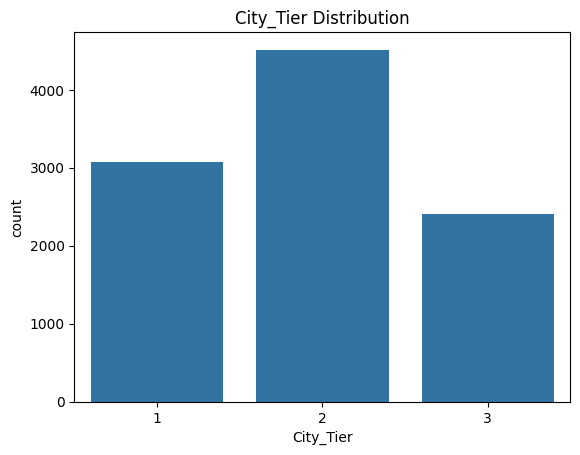

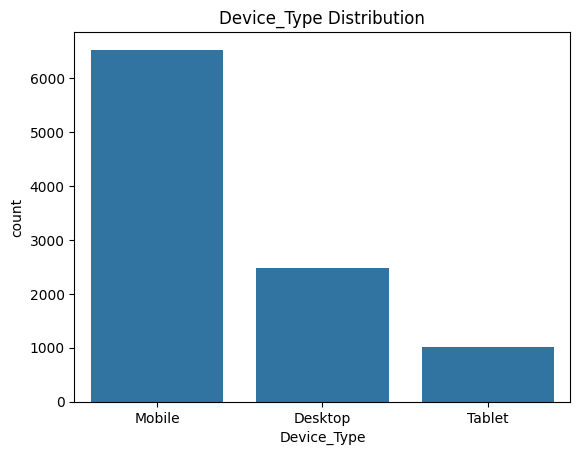

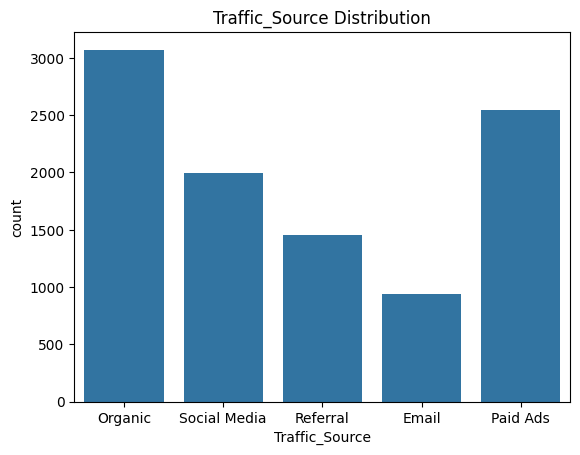

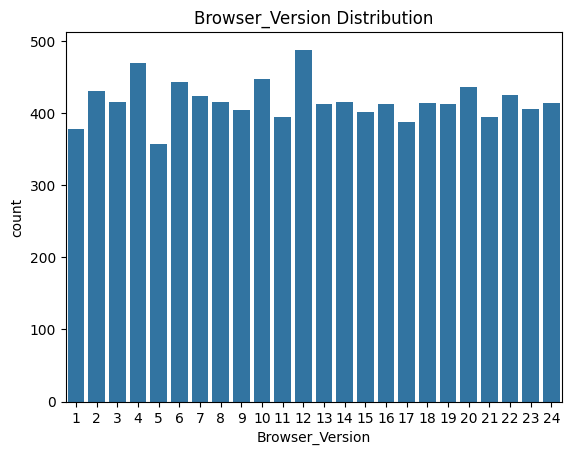

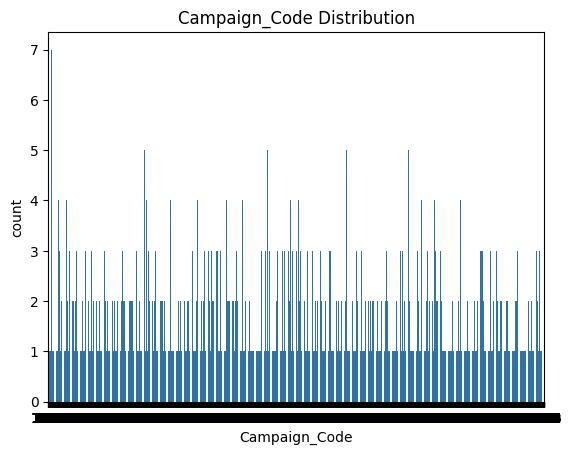

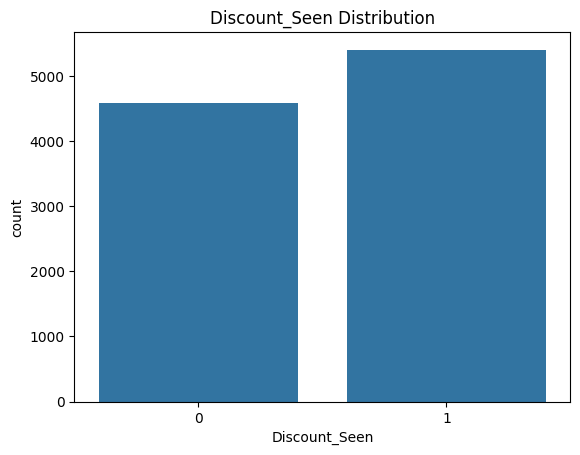

In [29]:
for col in categorical_cols:
    sns.countplot(data = train, x = col)

    plt.title(f"{col} Distribution")
    
    plt.show()

In [30]:
for col in categorical_cols:

    print(f"{col}: "f"{train[col].nunique()} unique values")

City_Tier: 3 unique values
Device_Type: 3 unique values
Traffic_Source: 5 unique values
Browser_Version: 24 unique values
Campaign_Code: 6014 unique values
Discount_Seen: 2 unique values


In [31]:
for col in categorical_cols:
    freq = train[col].value_counts(normalize = True)

    rare = freq[freq < 0.01]
    print(col)

    print(f"Rare Categories (<1%): " f"{len(rare)}")
    print(rare)

City_Tier
Rare Categories (<1%): 0
Series([], Name: proportion, dtype: float64)
Device_Type
Rare Categories (<1%): 0
Series([], Name: proportion, dtype: float64)
Traffic_Source
Rare Categories (<1%): 0
Series([], Name: proportion, dtype: float64)
Browser_Version
Rare Categories (<1%): 0
Series([], Name: proportion, dtype: float64)
Campaign_Code
Rare Categories (<1%): 6014
Campaign_Code
1359    0.0007
1062    0.0007
5921    0.0006
5051    0.0006
8909    0.0006
         ...  
7840    0.0001
9416    0.0001
8491    0.0001
9175    0.0001
7941    0.0001
Name: proportion, Length: 6014, dtype: float64
Discount_Seen
Rare Categories (<1%): 0
Series([], Name: proportion, dtype: float64)


In [32]:
summary = pd.DataFrame({'Feature':categorical_cols, 'Unique Values':[train[col].nunique() for col in categorical_cols], 'Most Frequent':[train[col].mode()[0] for col in categorical_cols], 'Frequency': [train[col].value_counts().iloc[0] for col in categorical_cols]})

summary

,Feature,Unique Values,Most Frequent,Frequency
0,City_Tier,3,2,4514
1,Device_Type,3,Mobile,6523
2,Traffic_Source,5,Organic,3071
3,Browser_Version,24,12,488
4,Campaign_Code,6014,1062,7
5,Discount_Seen,2,1,5407


In [33]:
train['Converted'].value_counts()

Converted
0    6913
1    3087
Name: count, dtype: int64

In [34]:
round(train['Converted'].value_counts(normalize = True) * 100, 2)

Converted
0    69.13
1    30.87
Name: proportion, dtype: float64

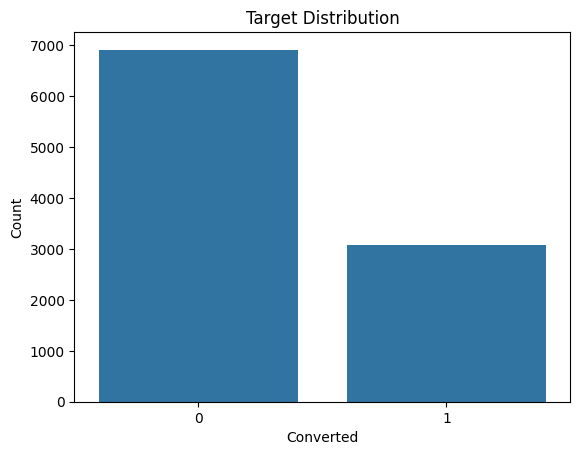

In [35]:
sns.countplot(data = train, x = 'Converted')

plt.title("Target Distribution")
plt.xlabel("Converted")
plt.ylabel("Count")

plt.show()

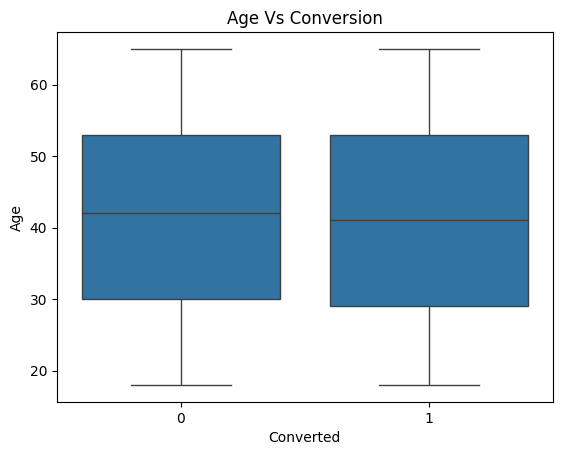

In [36]:
sns.boxplot(data = train, x = 'Converted', y = 'Age')

plt.title("Age Vs Conversion")

plt.show()

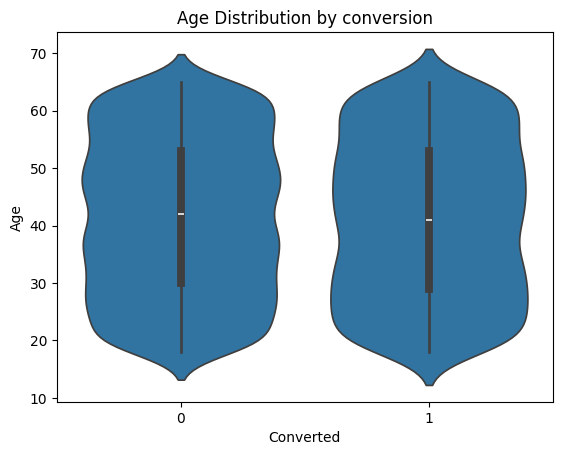

In [37]:
sns.violinplot(data = train, x = 'Converted', y = 'Age')

plt.title("Age Distribution by conversion")

plt.show()

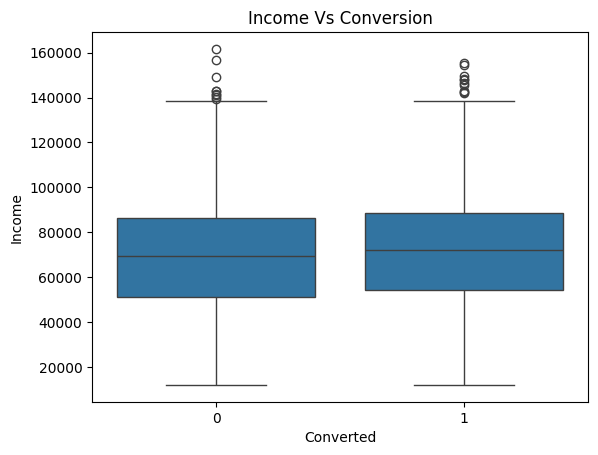

In [38]:
sns.boxplot(data = train, x = 'Converted', y = 'Income')

plt.title("Income Vs Conversion")

plt.show()

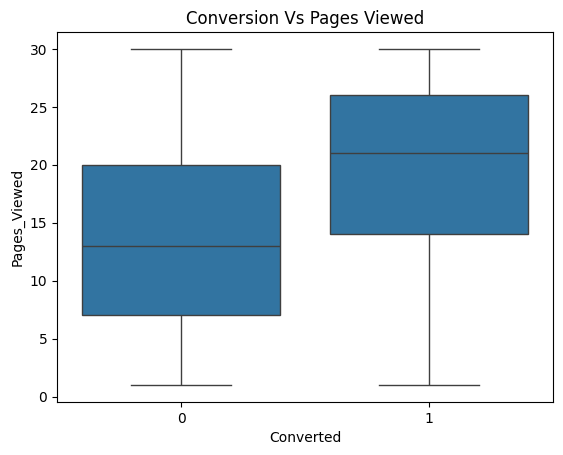

In [39]:
sns.boxplot(data = train, x = 'Converted', y = 'Pages_Viewed')

plt.title("Conversion Vs Pages Viewed")

plt.show()

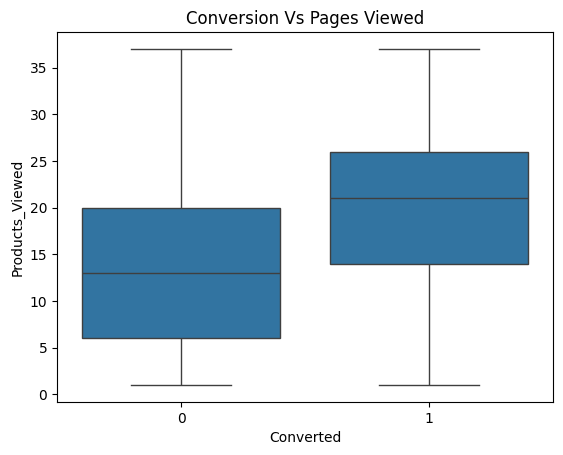

In [40]:
sns.boxplot(data = train, x = 'Converted', y = 'Products_Viewed')

plt.title("Conversion Vs Pages Viewed")

plt.show()

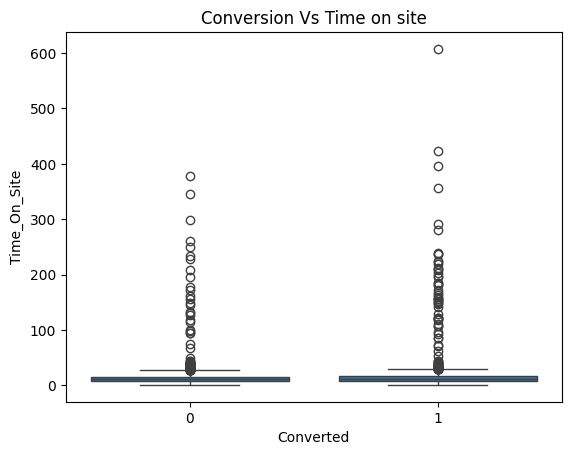

In [41]:
sns.boxplot(data = train, x = 'Converted', y = 'Time_On_Site')

plt.title("Conversion Vs Time on site")

plt.show()

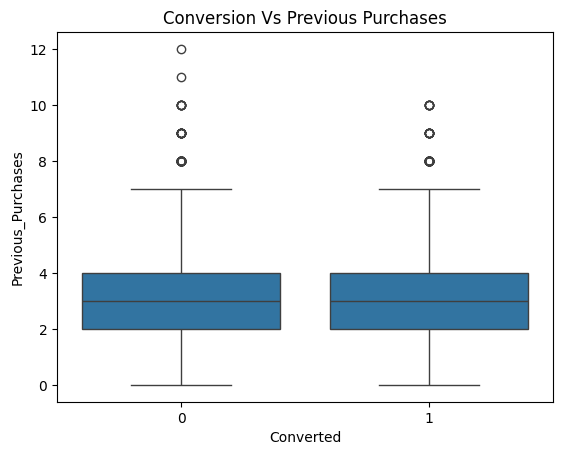

In [42]:
sns.boxplot(data = train, x = 'Converted', y = 'Previous_Purchases')

plt.title("Conversion Vs Previous Purchases")

plt.show()

In [43]:
numerical_cols = ['Age', 'Income', 'Pages_Viewed', 'Products_Viewed', 'Time_On_Site', 'Previous_Purchases']

for col in numerical_cols:
    print(col)

    print(train.groupby('Converted')[col].mean(), '\n')

Age
Converted
0    41.548475
1    41.253435
Name: Age, dtype: float64 

Income
Converted
0    69134.659095
1    71771.595850
Name: Income, dtype: float64 

Pages_Viewed
Converted
0    13.802546
1    19.652737
Name: Pages_Viewed, dtype: float64 

Products_Viewed
Converted
0    13.360480
1    19.381924
Name: Products_Viewed, dtype: float64 

Time_On_Site
Converted
0    12.597556
1    15.925828
Name: Time_On_Site, dtype: float64 

Previous_Purchases
Converted
0    2.859974
1    3.224490
Name: Previous_Purchases, dtype: float64 



In [44]:
device_conv = pd.crosstab(train['Device_Type'],train['Converted'],normalize='index')*100

device_conv

Converted,0,1
Device_Type,,
Desktop,66.909385,33.090615
Mobile,69.937145,30.062855
Tablet,69.353234,30.646766


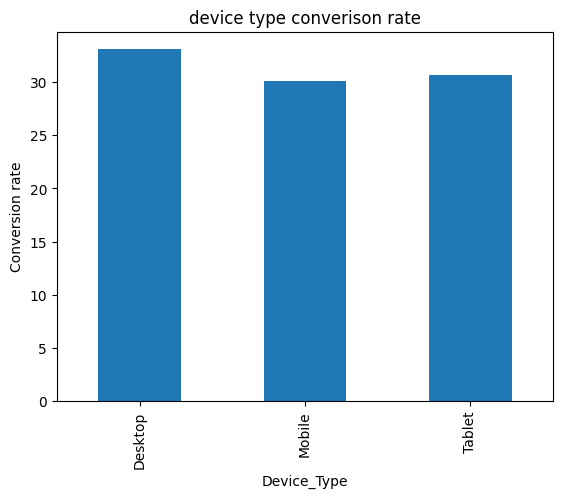

In [45]:
device_conv[1].plot(kind = 'bar')

plt.ylabel("Conversion rate")
plt.title("device type converison rate")

plt.show()

In [46]:
traffic_conv = pd.crosstab(train['Traffic_Source'], train['Converted'], normalize = 'index')*100

traffic_conv

Converted,0,1
Traffic_Source,,
Email,65.064103,34.935897
Organic,70.823836,29.176164
Paid Ads,72.287736,27.712264
Referral,61.881868,38.118132
Social Media,69.693929,30.306071


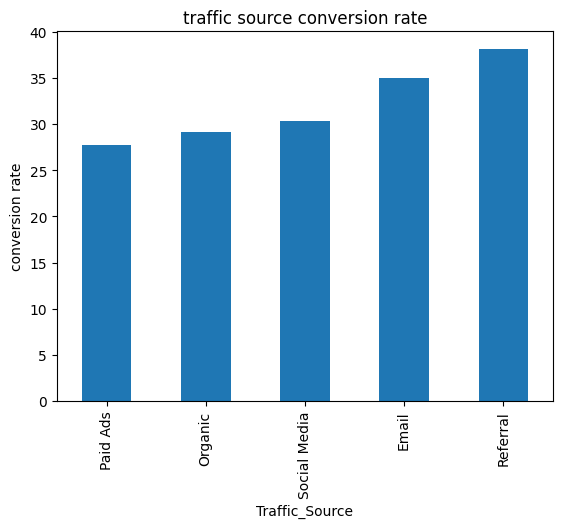

In [47]:
traffic_conv[1].sort_values().plot(kind = 'bar')

plt.ylabel("conversion rate")
plt.title("traffic source conversion rate")

plt.show()

In [48]:
city_conv = pd.crosstab(train['City_Tier'], train['Converted'], normalize = 'index')*100

city_conv

Converted,0,1
City_Tier,,
1,69.700910,30.299090
2,67.966327,32.033673
3,70.580913,29.419087


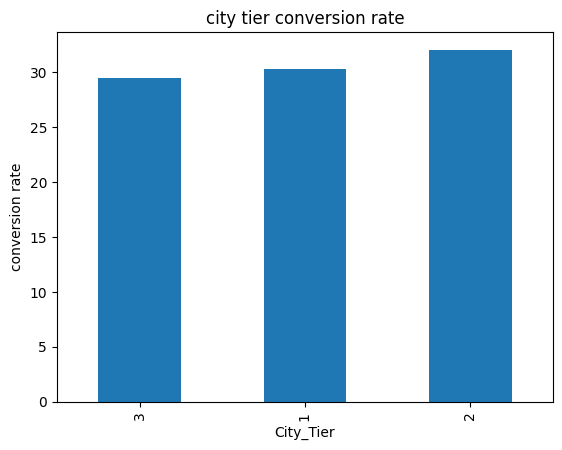

In [49]:
city_conv[1].sort_values().plot(kind = 'bar')

plt.ylabel("conversion rate")
plt.title("city tier conversion rate")

plt.show()

In [50]:
discount_conv = pd.crosstab(train['Discount_Seen'], train['Converted'], normalize = 'index')*100

discount_conv

Converted,0,1
Discount_Seen,,
0,74.482909,25.517091
1,64.582948,35.417052


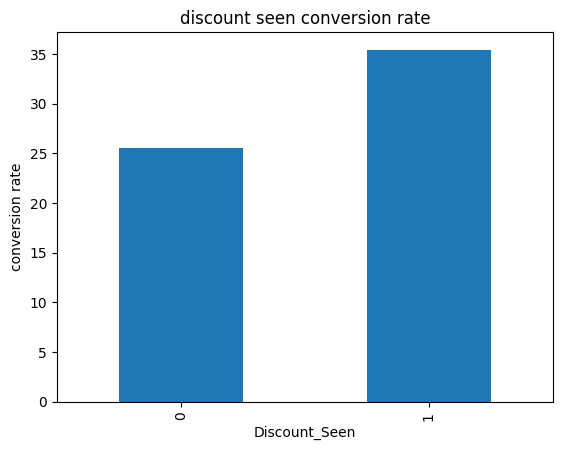

In [51]:
discount_conv[1].sort_values().plot(kind = 'bar')

plt.ylabel("conversion rate")
plt.title("discount seen conversion rate")

plt.show()

In [52]:
browser_conv = pd.crosstab(train['Browser_Version'], train['Converted'], normalize = 'index')*100

browser_conv

Converted,0,1
Browser_Version,,
1,69.841270,30.158730
2,70.997680,29.002320
3,71.394231,28.605769
4,69.296375,30.703625
5,67.507003,32.492997
6,61.625282,38.374718
7,69.976359,30.023641
8,70.913462,29.086538
9,68.564356,31.435644


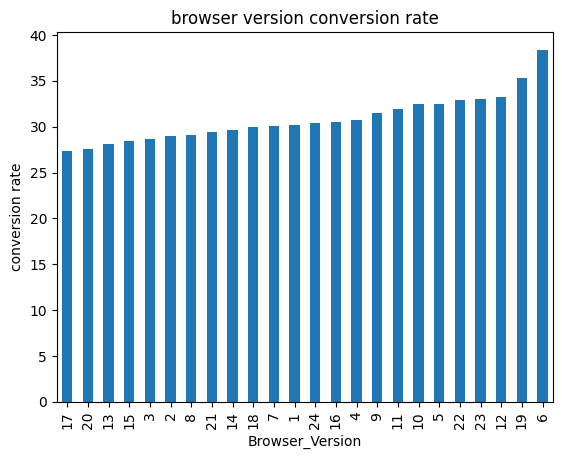

In [53]:
browser_conv[1].sort_values().plot(kind = 'bar')

plt.ylabel("conversion rate")
plt.title("browser version conversion rate")

plt.show()

In [54]:
train['Campaign_Code'].nunique()

6014

In [55]:
campaign_rates = train.groupby('Campaign_Code')['Converted'].mean()

campaign_rates.sort_values(ascending = False).head(10)

Campaign_Code
1004    1.0
1024    1.0
9998    1.0
1033    1.0
3087    1.0
3128    1.0
3127    1.0
3123    1.0
3110    1.0
3139    1.0
Name: Converted, dtype: float64

In [56]:
corr_matrix = train.corr(numeric_only = True)

corr_matrix

,User_ID,Age,Income,City_Tier,Pages_Viewed,Products_Viewed,Time_On_Site,Previous_Purchases,Discount_Seen,Browser_Version,Campaign_Code,Converted
User_ID,1.000000,0.004107,-0.016097,-0.004856,0.006595,0.007517,0.009151,0.002109,0.001548,-0.005924,0.002645,0.001201
Age,0.004107,1.000000,0.010502,0.012522,-0.026384,-0.026578,-0.000184,-0.009842,0.003511,-0.002583,-0.009328,-0.009888
Income,-0.016097,0.010502,1.000000,0.002894,-0.002871,-0.000448,0.009545,0.023117,0.018851,-0.000874,0.011486,0.049356
City_Tier,-0.004856,0.012522,0.002894,1.000000,0.019309,0.022490,0.026767,0.005667,0.018255,-0.001050,0.012049,-0.005108
Pages_Viewed,0.006595,-0.026384,-0.002871,0.019309,1.000000,0.945833,0.011252,-0.004934,-0.000004,0.000657,-0.000391,0.313409
Products_Viewed,0.007517,-0.026578,-0.000448,0.022490,0.945833,1.000000,0.013776,-0.000050,-0.001928,-0.003721,-0.003971,0.311595
Time_On_Site,0.009151,-0.000184,0.009545,0.026767,0.011252,0.013776,1.000000,-0.000670,0.009048,-0.023772,0.003820,0.079968
Previous_Purchases,0.002109,-0.009842,0.023117,0.005667,-0.004934,-0.000050,-0.000670,1.000000,-0.007653,-0.004695,-0.007392,0.096854
Discount_Seen,0.001548,0.003511,0.018851,0.018255,-0.000004,-0.001928,0.009048,-0.007653,1.000000,0.012188,-0.001487,0.106797
Browser_Version,-0.005924,-0.002583,-0.000874,-0.001050,0.000657,-0.003721,-0.023772,-0.004695,0.012188,1.000000,-0.015871,-0.001380


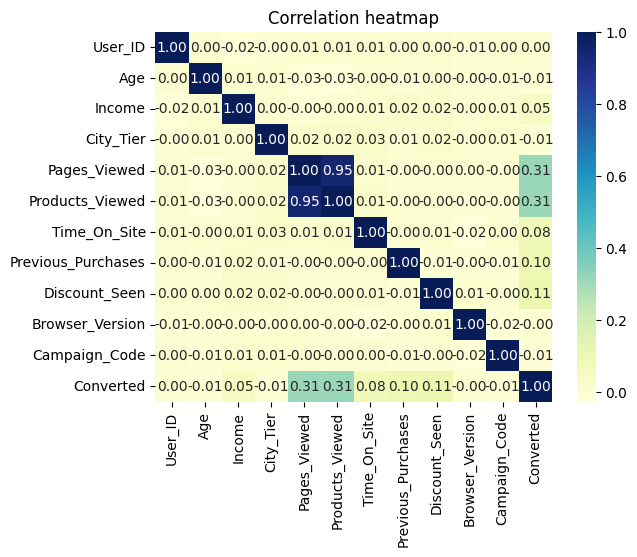

In [57]:
sns.heatmap(corr_matrix, annot = True, cmap = 'YlGnBu', fmt = '.2f')

plt.title('Correlation heatmap')

plt.show()

In [58]:
target_corr = (corr_matrix['Converted'].sort_values(ascending = False))

target_corr

Converted             1.000000
Pages_Viewed          0.313409
Products_Viewed       0.311595
Discount_Seen         0.106797
Previous_Purchases    0.096854
Time_On_Site          0.079968
Income                0.049356
User_ID               0.001201
Browser_Version      -0.001380
City_Tier            -0.005108
Campaign_Code        -0.008329
Age                  -0.009888
Name: Converted, dtype: float64

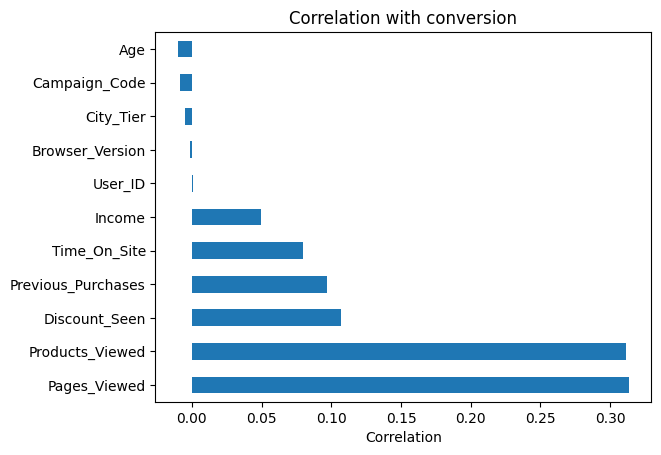

In [59]:
target_corr.drop('Converted').plot(kind = 'barh')

plt.title("Correlation with conversion")
plt.xlabel('Correlation')

plt.show()

In [60]:
corr_matrix.abs()

,User_ID,Age,Income,City_Tier,Pages_Viewed,Products_Viewed,Time_On_Site,Previous_Purchases,Discount_Seen,Browser_Version,Campaign_Code,Converted
User_ID,1.000000,0.004107,0.016097,0.004856,0.006595,0.007517,0.009151,0.002109,0.001548,0.005924,0.002645,0.001201
Age,0.004107,1.000000,0.010502,0.012522,0.026384,0.026578,0.000184,0.009842,0.003511,0.002583,0.009328,0.009888
Income,0.016097,0.010502,1.000000,0.002894,0.002871,0.000448,0.009545,0.023117,0.018851,0.000874,0.011486,0.049356
City_Tier,0.004856,0.012522,0.002894,1.000000,0.019309,0.022490,0.026767,0.005667,0.018255,0.001050,0.012049,0.005108
Pages_Viewed,0.006595,0.026384,0.002871,0.019309,1.000000,0.945833,0.011252,0.004934,0.000004,0.000657,0.000391,0.313409
Products_Viewed,0.007517,0.026578,0.000448,0.022490,0.945833,1.000000,0.013776,0.000050,0.001928,0.003721,0.003971,0.311595
Time_On_Site,0.009151,0.000184,0.009545,0.026767,0.011252,0.013776,1.000000,0.000670,0.009048,0.023772,0.003820,0.079968
Previous_Purchases,0.002109,0.009842,0.023117,0.005667,0.004934,0.000050,0.000670,1.000000,0.007653,0.004695,0.007392,0.096854
Discount_Seen,0.001548,0.003511,0.018851,0.018255,0.000004,0.001928,0.009048,0.007653,1.000000,0.012188,0.001487,0.106797
Browser_Version,0.005924,0.002583,0.000874,0.001050,0.000657,0.003721,0.023772,0.004695,0.012188,1.000000,0.015871,0.001380


In [61]:
important_cols = ['Pages_Viewed','Products_Viewed','Time_On_Site','Previous_Purchases','Converted']

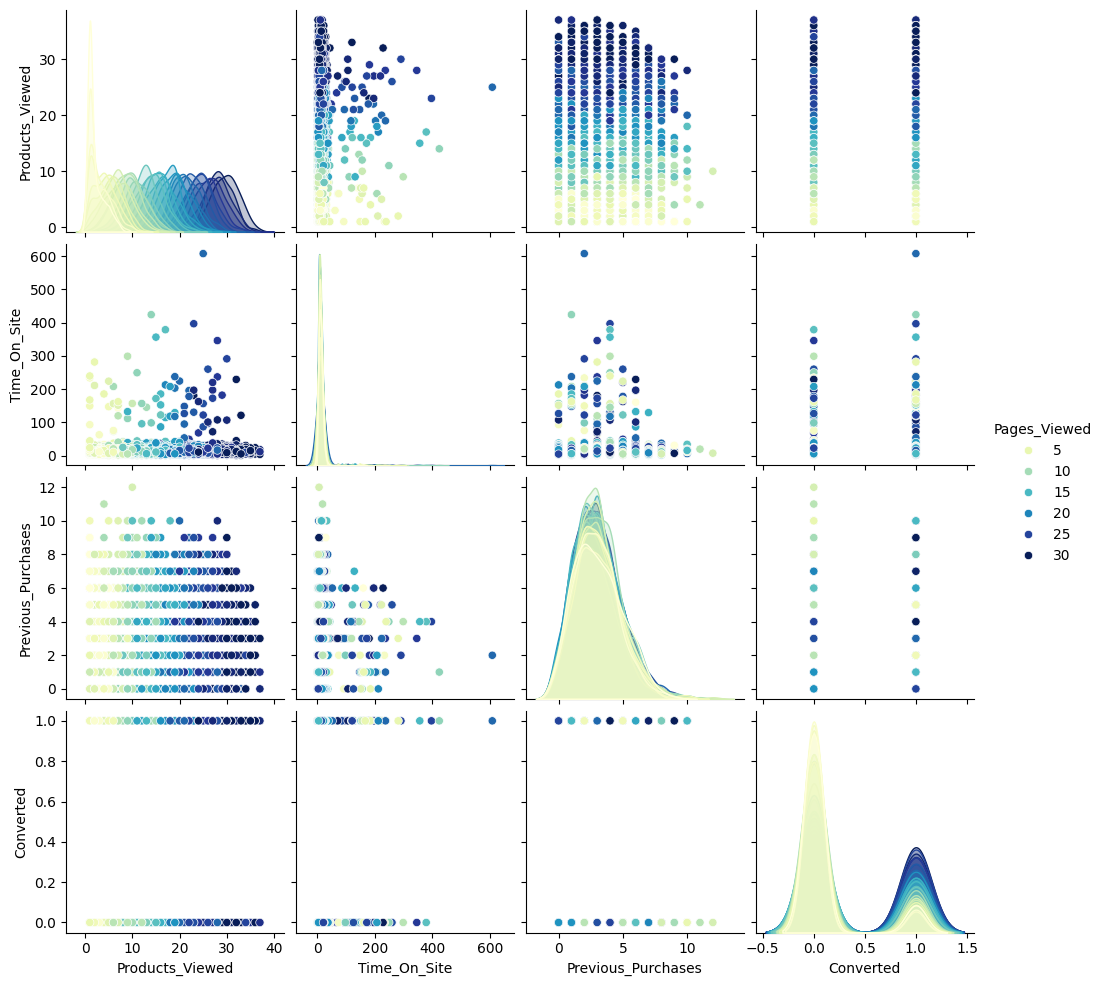

In [62]:
sns.pairplot(train[important_cols], palette = 'YlGnBu', hue = 'Pages_Viewed')

plt.show()

In [63]:
correlation_report = pd.DataFrame({'Feature': target_corr.index, 'Correlation':target_corr.values})

correlation_report

,Feature,Correlation
0,Converted,1.000000
1,Pages_Viewed,0.313409
2,Products_Viewed,0.311595
3,Discount_Seen,0.106797
4,Previous_Purchases,0.096854
5,Time_On_Site,0.079968
6,Income,0.049356
7,User_ID,0.001201
8,Browser_Version,-0.001380
9,City_Tier,-0.005108


In [64]:
train_processed = train.copy()
public_processed = public.copy()
private_processed = private.copy()


In [65]:
numerical_missing_cols = ['Age', 'Income', 'Time_On_Site']

for col in numerical_missing_cols:
    median_value = train_processed[col].median()

    train_processed[col] = (train_processed[col].fillna(median_value))

    public_processed[col] = (public_processed[col].fillna(median_value))

    private_processed[col] = (private_processed[col].fillna(median_value))

In [66]:
train_processed[numerical_missing_cols].isnull().sum()

Age             0
Income          0
Time_On_Site    0
dtype: int64

In [67]:
for col in numerical_cols:
    Q1 = train_processed[col].quantile(0.25)
    Q3 = train_processed[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = train_processed[(train_processed[col] < lower) | (train_processed[col] > upper)]

    print(f"{col}: {len(outliers)} outliers", '\n')

Age: 0 outliers 

Income: 62 outliers 

Pages_Viewed: 0 outliers 

Products_Viewed: 0 outliers 

Time_On_Site: 483 outliers 

Previous_Purchases: 125 outliers 



In [68]:
train_processed.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   User_ID             10000 non-null  int64  
 1   Age                 10000 non-null  float64
 2   Income              10000 non-null  float64
 3   City_Tier           10000 non-null  int64  
 4   Device_Type         10000 non-null  str    
 5   Traffic_Source      10000 non-null  str    
 6   Pages_Viewed        10000 non-null  int64  
 7   Products_Viewed     10000 non-null  int64  
 8   Time_On_Site        10000 non-null  float64
 9   Previous_Purchases  10000 non-null  int64  
 10  Discount_Seen       10000 non-null  int64  
 11  Browser_Version     10000 non-null  int64  
 12  Campaign_Code       10000 non-null  int64  
 13  Converted           10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
memory usage: 1.1 MB


In [69]:
train_processed.isnull().sum().sum()

np.int64(0)

In [70]:
train_processed['Engagement_Score'] = (train_processed['Pages_Viewed'] + train_processed['Products_Viewed'])

public_processed['Engagement_Score'] = (public_processed['Pages_Viewed'] + public_processed['Products_Viewed'])

private_processed['Engagement_Score'] = (private_processed['Pages_Viewed'] + private_processed['Products_Viewed'])

In [71]:
train_processed['Product_Interest_Ratio'] = (train_processed['Products_Viewed']/(train_processed['Pages_Viewed'] + 1))

public_processed['Product_Interest_Ratio'] = (public_processed['Products_Viewed']/(public_processed['Pages_Viewed'] + 1))

private_processed['Product_Interest_Ratio'] = (private_processed['Products_Viewed']/(private_processed['Pages_Viewed'] + 1))

In [72]:
train_processed['Returning_Customer'] = (train_processed['Previous_Purchases'] > 0).astype(int)

public_processed['Returning_Customer'] = (public_processed['Previous_Purchases'] > 0).astype(int)

private_processed['Returning_Customer'] = (private_processed['Previous_Purchases'] > 0).astype(int)

In [73]:
train_processed['Income_Time_Ratio'] = (train_processed['Income']/(train_processed['Time_On_Site'] + 1))

public_processed['Income_Time_Ratio'] = (public_processed['Income']/(public_processed['Time_On_Site'] + 1))

private_processed['Income_Time_Ratio'] = (private_processed['Income']/(private_processed['Time_On_Site'] + 1))

In [74]:
engagement_median = (train_processed['Pages_Viewed'].median())

In [75]:
engagement_median

np.float64(16.0)

In [76]:
train_processed['High_Engagement'] = (train_processed['Pages_Viewed'] > engagement_median).astype(int)

public_processed['High_Engagement'] = (public_processed['Pages_Viewed'] > engagement_median).astype(int)

private_processed['High_Engagement'] = (private_processed['Pages_Viewed'] > engagement_median).astype(int)

In [77]:
new_features = ['Engagement_Score', 'Product_Interest_Ratio', 'Returning_Customer', 'Income_Time_Ratio', 'High_Engagement']

train_processed[new_features].head()

,Engagement_Score,Product_Interest_Ratio,Returning_Customer,Income_Time_Ratio,High_Engagement
0,9,0.666667,1,9763.780284,0
1,14,0.250000,1,1956.613901,0
2,2,0.500000,1,2141.138856,0
3,26,0.800000,1,7228.420942,0
4,35,1.400000,1,5872.167917,0


In [78]:
print(train.shape)

(10000, 14)


In [79]:
print(train_processed.shape)

(10000, 19)


In [80]:
categorical_cols = ['City_Tier', 'Device_Type', 'Traffic_Source', 'Browser_Version', 'Campaign_Code']

for col in categorical_cols:
    print(f'{col}')
    print(train_processed[col].nunique())

City_Tier
3
Device_Type
3
Traffic_Source
5
Browser_Version
24
Campaign_Code
6014


In [81]:
from sklearn.preprocessing import LabelEncoder

browser_encoder = LabelEncoder()

train_processed['Browser_Version'] = (browser_encoder.fit_transform(train_processed['Browser_Version']))

public_processed['Browser_Version'] = (browser_encoder.transform(public_processed['Browser_Version']))

private_processed['Browser_Version'] = (browser_encoder.transform(private_processed['Browser_Version']))

In [82]:
   # campaign_encoder = LabelEncoder()
    
  #  train_processed['Campaign_Code'] = (campaign_encoder.fit_transform(train_processed['Campaign_Code']))
    
   # public_processed['Campaign_Code'] = (campaign_encoder.transform(public_processed['Campaign_Code']))
    
    #private_processed['Campaign_Code'] = (campaign_encoder.transform(private_processed['Campaign_Code']))

In [83]:
print(train_processed['Campaign_Code'].nunique())
print(public_processed['Campaign_Code'].nunique())
print(private_processed['Campaign_Code'].nunique())

6014
2559
2523


In [84]:
train_processed.drop(
    columns=['Campaign_Code'],
    inplace=True
)

public_processed.drop(
    columns=['Campaign_Code'],
    inplace=True
)

private_processed.drop(
    columns=['Campaign_Code'],
    inplace=True
)

In [85]:
train_processed['Browser_Version'].nunique()

24

In [86]:
'Campaign_Code' in train_processed.columns

False

In [87]:
train_processed.head()

,User_ID,Age,Income,City_Tier,Device_Type,Traffic_Source,Pages_Viewed,Products_Viewed,Time_On_Site,Previous_Purchases,Discount_Seen,Browser_Version,Converted,Engagement_Score,Product_Interest_Ratio,Returning_Customer,Income_Time_Ratio,High_Engagement
0,1,58.0,103593.708812,2,Mobile,Organic,5,4,9.610,3,0,10,0,9,0.666667,1,9763.780284,0
1,2,26.0,36451.716984,2,Mobile,Social Media,11,3,17.630,2,0,13,0,14,0.250000,1,1956.613901,0
2,3,19.0,30511.228700,3,Mobile,Referral,1,1,13.250,5,0,4,0,2,0.500000,1,2141.138856,0
3,4,48.0,87789.172342,3,Mobile,Email,14,12,11.145,1,1,18,0,26,0.800000,1,7228.420942,0
4,5,35.0,105229.249067,2,Mobile,Social Media,14,21,16.920,1,0,4,0,35,1.400000,1,5872.167917,0


In [88]:
train_processed.drop(columns = ['Campaign_Code'], inplace = True, errors = 'ignore')

public_processed.drop(columns = ['Campaign_Code'], inplace = True, errors = 'ignore')

private_processed.drop(columns = ['Campaign_Code'], inplace = True, errors = 'ignore')

In [89]:
for df_name, df in {"Train": train_processed, "Public": public_processed, "Private": private_processed}.items():

    print(f"{df_name}:", 'Campaign_Code' in df.columns)

Train: False
Public: False
Private: False


In [90]:
from sklearn.preprocessing import LabelEncoder

browser_encoder = LabelEncoder()

all_browser_versions = pd.concat([train_processed['Browser_Version'], public_processed['Browser_Version'], private_processed['Browser_Version']])

browser_encoder.fit(all_browser_versions)

train_processed['Browser_Version'] = browser_encoder.transform(train_processed['Browser_Version'])

public_processed['Browser_Version'] = browser_encoder.transform(public_processed['Browser_Version'])

private_processed['Browser_Version'] = browser_encoder.transform(private_processed['Browser_Version'])

In [91]:
train_processed.shape

(10000, 18)

In [92]:
train_processed.columns

Index(['User_ID', 'Age', 'Income', 'City_Tier', 'Device_Type',
       'Traffic_Source', 'Pages_Viewed', 'Products_Viewed', 'Time_On_Site',
       'Previous_Purchases', 'Discount_Seen', 'Browser_Version', 'Converted',
       'Engagement_Score', 'Product_Interest_Ratio', 'Returning_Customer',
       'Income_Time_Ratio', 'High_Engagement'],
      dtype='str')

In [93]:
combined = pd.concat(
    [
        train_processed.drop(columns=['Converted']),
        public_processed.drop(columns=['Converted']),
        private_processed
    ]
)

combined = pd.get_dummies(
    combined,
    columns=['Device_Type', 'Traffic_Source'],
    drop_first=True
)

train_rows = len(train_processed)
public_rows = len(public_processed)

train_features = combined.iloc[:train_rows]

public_features = combined.iloc[
    train_rows:train_rows + public_rows
]

private_features = combined.iloc[
    train_rows + public_rows:
]

train_features['Converted'] = (
    train_processed['Converted'].values
)

public_features['Converted'] = (
    public_processed['Converted'].values
)

In [94]:
train_processed.shape

(10000, 18)

In [95]:
train_processed.columns

Index(['User_ID', 'Age', 'Income', 'City_Tier', 'Device_Type',
       'Traffic_Source', 'Pages_Viewed', 'Products_Viewed', 'Time_On_Site',
       'Previous_Purchases', 'Discount_Seen', 'Browser_Version', 'Converted',
       'Engagement_Score', 'Product_Interest_Ratio', 'Returning_Customer',
       'Income_Time_Ratio', 'High_Engagement'],
      dtype='str')

In [96]:
one_hot_cols = [
    'Device_Type',
    'Traffic_Source'
]

In [97]:
combined = pd.concat([
    train_processed.drop(columns=['Converted']),
    public_processed.drop(columns=['Converted']),
    private_processed
])

In [98]:
combined = pd.get_dummies(
    combined,
    columns=one_hot_cols,
    drop_first=True
)

In [99]:
train_rows = len(train_processed)
public_rows = len(public_processed)

In [100]:
train_features = combined.iloc[:train_rows].copy()

public_features = combined.iloc[
    train_rows:train_rows + public_rows
].copy()

private_features = combined.iloc[
    train_rows + public_rows:
].copy()

In [101]:
train_features['Converted'] = (
    train_processed['Converted'].values
)

public_features['Converted'] = (
    public_processed['Converted'].values
)

In [102]:
print(train_features.shape)
print(public_features.shape)
print(private_features.shape)

(10000, 22)
(3000, 22)
(3000, 21)


In [103]:
print(train_features.head())

   User_ID   Age         Income  City_Tier  Pages_Viewed  Products_Viewed  \
0        1  58.0  103593.708812          2             5                4   
1        2  26.0   36451.716984          2            11                3   
2        3  19.0   30511.228700          3             1                1   
3        4  48.0   87789.172342          3            14               12   
4        5  35.0  105229.249067          2            14               21   

   Time_On_Site  Previous_Purchases  Discount_Seen  Browser_Version  ...  \
0         9.610                   3              0               10  ...   
1        17.630                   2              0               13  ...   
2        13.250                   5              0                4  ...   
3        11.145                   1              1               18  ...   
4        16.920                   1              0                4  ...   

   Returning_Customer  Income_Time_Ratio  High_Engagement  Device_Type_Mobile  \

In [104]:
X = train_features.drop(
    columns=['Converted']
)

y = train_features['Converted']

In [105]:
print(X.shape)
print(y.shape)

(10000, 21)
(10000,)


In [106]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [107]:
train_features.isnull().sum().sum()

np.int64(0)

In [108]:
print(X_train.shape)
print(X_valid.shape)

(8000, 21)
(2000, 21)


In [109]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [110]:
lr_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

lr_model.fit(
    X_train,
    y_train
)

C:\Users\LENOVO\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [111]:
lr_pred = lr_model.predict(
    X_valid
)

In [112]:
print("Accuracy:",
      accuracy_score(
          y_valid,
          lr_pred
      ))

print("Precision:",
      precision_score(
          y_valid,
          lr_pred
      ))

print("Recall:",
      recall_score(
          y_valid,
          lr_pred
      ))

print("F1 Score:",
      f1_score(
          y_valid,
          lr_pred
      ))

Accuracy: 0.693
Precision: 0.5050847457627119
Recall: 0.24149108589951376
F1 Score: 0.3267543859649123


In [113]:
print(
    classification_report(
        y_valid,
        lr_pred
    )
)

              precision    recall  f1-score   support

           0       0.73      0.89      0.80      1383
           1       0.51      0.24      0.33       617

    accuracy                           0.69      2000
   macro avg       0.62      0.57      0.56      2000
weighted avg       0.66      0.69      0.65      2000



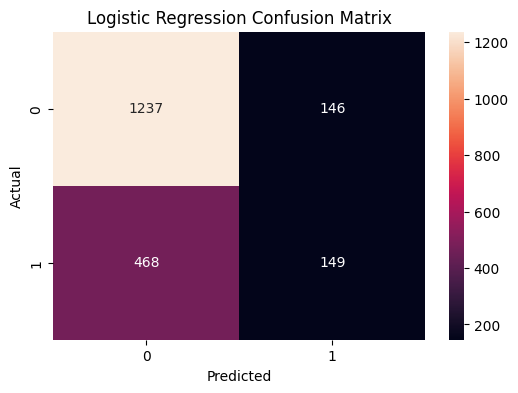

In [114]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_valid,
    lr_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    'Logistic Regression Confusion Matrix'
)

plt.xlabel(
    'Predicted'
)

plt.ylabel(
    'Actual'
)

plt.show()

In [115]:
importance = pd.DataFrame({

    'Feature': X.columns,

    'Coefficient':
    lr_model.coef_[0]

})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

importance.head(15)

,Feature,Coefficient
8,Discount_Seen,4.061197e-01
19,Traffic_Source_Referral,1.663886e-01
14,High_Engagement,1.003439e-01
5,Products_Viewed,3.243731e-02
10,Engagement_Score,2.441664e-02
7,Previous_Purchases,1.228209e-02
6,Time_On_Site,6.696054e-03
2,Income,6.755896e-08
13,Income_Time_Ratio,-9.426210e-06
0,User_ID,-2.159779e-05


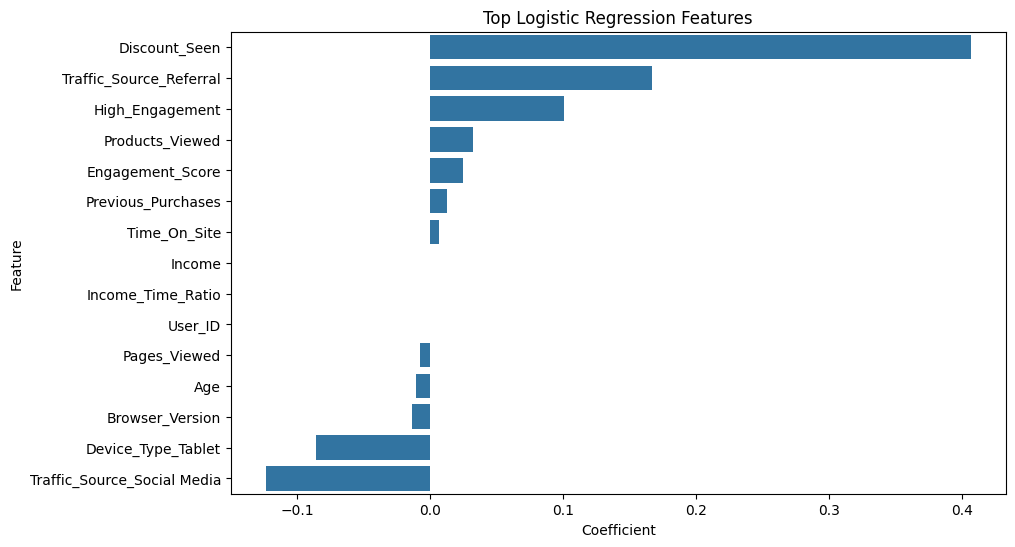

In [116]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x='Coefficient',
    y='Feature'
)

plt.title(
    'Top Logistic Regression Features'
)

plt.show()

In [117]:
print('User_ID' in train_features.columns)

True


In [118]:
train_features.drop(
    columns=['User_ID'],
    inplace=True
)

public_features.drop(
    columns=['User_ID'],
    inplace=True
)

private_features.drop(
    columns=['User_ID'],
    inplace=True
)

In [119]:
X = train_features.drop(
    columns=['Converted']
)

y = train_features['Converted']

In [120]:
print('User_ID' in train_features.columns)

False


In [121]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [122]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total n

In [123]:
rf_pred = rf_model.predict(
    X_valid
)

In [124]:
print(
    "Accuracy:",
    accuracy_score(
        y_valid,
        rf_pred
    )
)

print(
    "Precision:",
    precision_score(
        y_valid,
        rf_pred
    )
)

print(
    "Recall:",
    recall_score(
        y_valid,
        rf_pred
    )
)

print(
    "F1 Score:",
    f1_score(
        y_valid,
        rf_pred
    )
)

Accuracy: 0.71
Precision: 0.5622895622895623
Recall: 0.2706645056726094
F1 Score: 0.36542669584245074


In [125]:
print(
    classification_report(
        y_valid,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.74      0.91      0.81      1383
           1       0.56      0.27      0.37       617

    accuracy                           0.71      2000
   macro avg       0.65      0.59      0.59      2000
weighted avg       0.68      0.71      0.67      2000



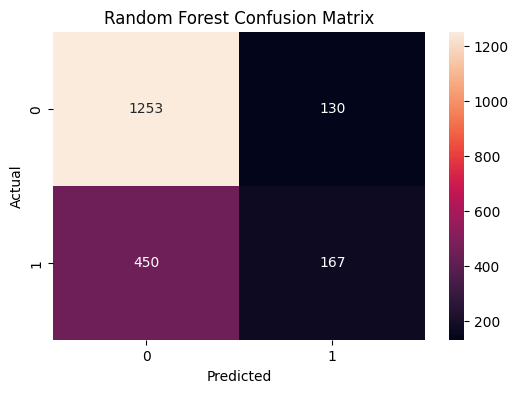

In [126]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_valid,
    rf_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    'Random Forest Confusion Matrix'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [127]:
importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance':
    rf_model.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(15)

ValueError: All arrays must be of the same length

In [128]:
print("Columns in X:", len(X.columns))

print("Importances:", len(rf_model.feature_importances_))

Columns in X: 20
Importances: 21


In [129]:
X = train_features.drop(
    columns=['Converted']
)

y = train_features['Converted']

In [130]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [131]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total n

In [132]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(15)

,Feature,Importance
9,Engagement_Score,0.126145
3,Pages_Viewed,0.111883
4,Products_Viewed,0.102466
5,Time_On_Site,0.095354
12,Income_Time_Ratio,0.086704
1,Income,0.080922
10,Product_Interest_Ratio,0.071908
0,Age,0.059060
8,Browser_Version,0.057039
6,Previous_Purchases,0.051107


In [133]:
print(len(X.columns))
print(len(rf_model.feature_importances_))

20
20


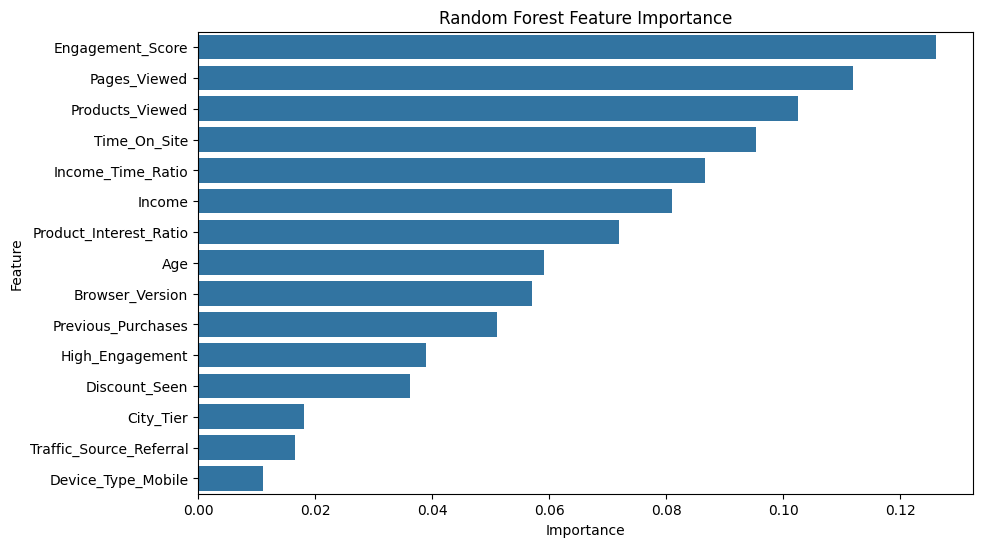

In [134]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title(
    'Random Forest Feature Importance'
)

plt.show()

In [135]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(15)

,Feature,Importance
9,Engagement_Score,0.126145
3,Pages_Viewed,0.111883
4,Products_Viewed,0.102466
5,Time_On_Site,0.095354
12,Income_Time_Ratio,0.086704
1,Income,0.080922
10,Product_Interest_Ratio,0.071908
0,Age,0.059060
8,Browser_Version,0.057039
6,Previous_Purchases,0.051107


In [136]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_valid, rf_pred))
print("Precision:", precision_score(y_valid, rf_pred))
print("Recall   :", recall_score(y_valid, rf_pred))
print("F1 Score :", f1_score(y_valid, rf_pred))

Accuracy : 0.71
Precision: 0.5622895622895623
Recall   : 0.2706645056726094
F1 Score : 0.36542669584245074


In [137]:
!pip install catboost

Defaulting to user installation because normal site-packages is not writeable


In [138]:
from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [139]:
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_state=42,
    verbose=0
)

cat_model.fit(
    X_train,
    y_train
)

CatBoostClassifier(depth=6, iterations=500, learning_rate=0.05, random_state=42, verbose=0)

In [140]:
cat_pred = cat_model.predict(
    X_valid
)

In [141]:
print("Accuracy :", accuracy_score(y_valid, cat_pred))
print("Precision:", precision_score(y_valid, cat_pred))
print("Recall   :", recall_score(y_valid, cat_pred))
print("F1 Score :", f1_score(y_valid, cat_pred))

Accuracy : 0.701
Precision: 0.5258855585831063
Recall   : 0.31280388978930307
F1 Score : 0.39227642276422764


In [142]:
print(
    classification_report(
        y_valid,
        cat_pred
    )
)

              precision    recall  f1-score   support

           0       0.74      0.87      0.80      1383
           1       0.53      0.31      0.39       617

    accuracy                           0.70      2000
   macro avg       0.63      0.59      0.60      2000
weighted avg       0.67      0.70      0.68      2000



In [143]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': cat_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(15)

,Feature,Importance
5,Time_On_Site,10.648763
10,Product_Interest_Ratio,10.376579
1,Income,9.702933
12,Income_Time_Ratio,8.813469
8,Browser_Version,8.182241
0,Age,8.049485
3,Pages_Viewed,7.739631
9,Engagement_Score,6.405516
4,Products_Viewed,6.403105
6,Previous_Purchases,5.985519


In [144]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

weights

array([0.72332731, 1.6194332 ])

In [145]:
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_state=42,
    verbose=0,
    class_weights=[0.72, 1.61]
)

In [146]:
print("Accuracy :", accuracy_score(y_valid, cat_pred))
print("Precision:", precision_score(y_valid, cat_pred))
print("Recall   :", recall_score(y_valid, cat_pred))
print("F1 Score :", f1_score(y_valid, cat_pred))

Accuracy : 0.701
Precision: 0.5258855585831063
Recall   : 0.31280388978930307
F1 Score : 0.39227642276422764


In [147]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_valid, cat_pred))
print("Precision:", precision_score(y_valid, cat_pred))
print("Recall   :", recall_score(y_valid, cat_pred))
print("F1 Score :", f1_score(y_valid, cat_pred))

Accuracy : 0.701
Precision: 0.5258855585831063
Recall   : 0.31280388978930307
F1 Score : 0.39227642276422764


In [148]:
from sklearn.metrics import classification_report

print(classification_report(y_valid, cat_pred))

              precision    recall  f1-score   support

           0       0.74      0.87      0.80      1383
           1       0.53      0.31      0.39       617

    accuracy                           0.70      2000
   macro avg       0.63      0.59      0.60      2000
weighted avg       0.67      0.70      0.68      2000



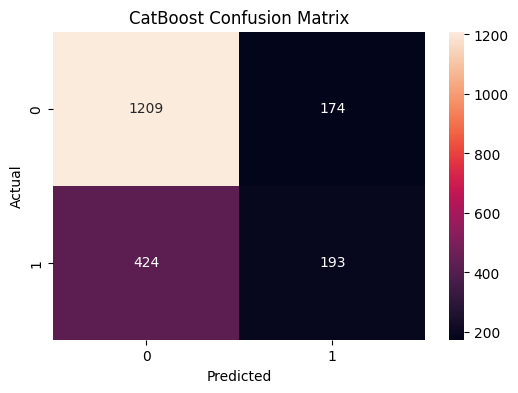

In [149]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid, cat_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title('CatBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [150]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

print(weights)

[0.72332731 1.6194332 ]


In [151]:
cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=8,
    random_state=42,
    verbose=100,
    class_weights=list(weights)
)

cat_model.fit(
    X_train,
    y_train
)

0:	learn: 0.6882570	total: 12.5ms	remaining: 12.5s
100:	learn: 0.5534147	total: 932ms	remaining: 8.29s
200:	learn: 0.5039914	total: 1.83s	remaining: 7.26s
300:	learn: 0.4620257	total: 2.67s	remaining: 6.21s
400:	learn: 0.4240057	total: 3.49s	remaining: 5.22s
500:	learn: 0.3908408	total: 4.33s	remaining: 4.31s
600:	learn: 0.3616878	total: 5.16s	remaining: 3.43s
700:	learn: 0.3346724	total: 5.99s	remaining: 2.55s
800:	learn: 0.3112632	total: 6.8s	remaining: 1.69s
900:	learn: 0.2887244	total: 7.7s	remaining: 846ms
999:	learn: 0.2684346	total: 8.5s	remaining: 0us


CatBoostClassifier(class_weights=[np.float64(0.7233273056057866), np.float64(1.6194331983805668)], depth=8, iterations=1000, learning_rate=0.03, random_state=42, verbose=100)

In [152]:
cat_pred = cat_model.predict(X_valid)

from sklearn.metrics import classification_report

print(classification_report(
    y_valid,
    cat_pred
))

              precision    recall  f1-score   support

           0       0.78      0.71      0.75      1383
           1       0.46      0.56      0.51       617

    accuracy                           0.66      2000
   macro avg       0.62      0.63      0.63      2000
weighted avg       0.68      0.66      0.67      2000



In [153]:
train_processed['Pages_Per_Minute'] = (
    train_processed['Pages_Viewed']
    /
    (train_processed['Time_On_Site'] + 1)
)

public_processed['Pages_Per_Minute'] = (
    public_processed['Pages_Viewed']
    /
    (public_processed['Time_On_Site'] + 1)
)

private_processed['Pages_Per_Minute'] = (
    private_processed['Pages_Viewed']
    /
    (private_processed['Time_On_Site'] + 1)
)

In [154]:
train_processed['Products_Per_Minute'] = (
    train_processed['Products_Viewed']
    /
    (train_processed['Time_On_Site'] + 1)
)

public_processed['Products_Per_Minute'] = (
    public_processed['Products_Viewed']
    /
    (public_processed['Time_On_Site'] + 1)
)

private_processed['Products_Per_Minute'] = (
    private_processed['Products_Viewed']
    /
    (private_processed['Time_On_Site'] + 1)
)

In [155]:
train_processed['Purchase_Engagement'] = (
    train_processed['Previous_Purchases']
    *
    train_processed['Engagement_Score']
)

public_processed['Purchase_Engagement'] = (
    public_processed['Previous_Purchases']
    *
    public_processed['Engagement_Score']
)

private_processed['Purchase_Engagement'] = (
    private_processed['Previous_Purchases']
    *
    private_processed['Engagement_Score']
)

In [156]:
from sklearn.metrics import classification_report

print(classification_report(y_valid, cat_pred))

              precision    recall  f1-score   support

           0       0.78      0.71      0.75      1383
           1       0.46      0.56      0.51       617

    accuracy                           0.66      2000
   macro avg       0.62      0.63      0.63      2000
weighted avg       0.68      0.66      0.67      2000



In [157]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': cat_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(15))

                    Feature  Importance
5              Time_On_Site    9.527970
1                    Income    9.474474
10   Product_Interest_Ratio    9.428470
8           Browser_Version    9.384798
0                       Age    9.037954
12        Income_Time_Ratio    8.171529
6        Previous_Purchases    6.805563
9          Engagement_Score    6.224166
3              Pages_Viewed    5.594704
4           Products_Viewed    5.107510
2                 City_Tier    4.673551
7             Discount_Seen    4.546377
14       Device_Type_Mobile    2.376937
16   Traffic_Source_Organic    2.246103
17  Traffic_Source_Paid Ads    2.155833


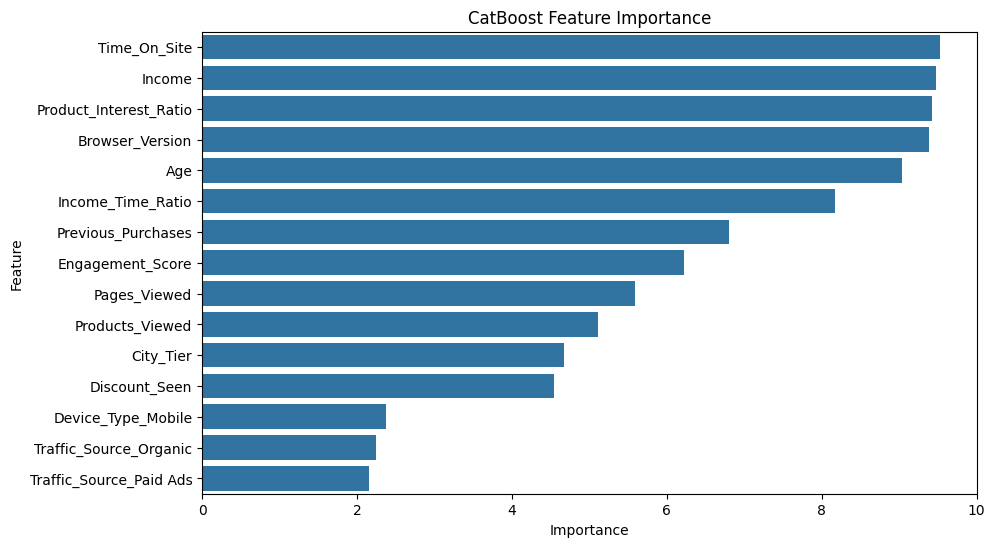

In [158]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title('CatBoost Feature Importance')

plt.show()

In [159]:
for df in [train_processed, public_processed, private_processed]:

    df['Pages_Per_Minute'] = (
        df['Pages_Viewed'] /
        (df['Time_On_Site'] + 1)
    )

    df['Products_Per_Minute'] = (
        df['Products_Viewed'] /
        (df['Time_On_Site'] + 1)
    )

    df['Purchase_Engagement'] = (
        df['Previous_Purchases'] *
        df['Engagement_Score']
    )

In [176]:
X = train_features.drop(
    columns=['Converted']
)

In [177]:
from sklearn.metrics import classification_report

print(classification_report(y_valid, cat_pred))

              precision    recall  f1-score   support

           0       0.78      0.71      0.75      1383
           1       0.46      0.56      0.51       617

    accuracy                           0.66      2000
   macro avg       0.62      0.63      0.63      2000
weighted avg       0.68      0.66      0.67      2000



In [178]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [179]:
from xgboost import XGBClassifier

In [180]:
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    scale_pos_weight=2.2,
    eval_metric='logloss'
)

xgb_model.fit(
    X_train,
    y_train
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [181]:
xgb_pred = xgb_model.predict(X_valid)

In [182]:
from sklearn.metrics import classification_report

print(classification_report(
    y_valid,
    xgb_pred
))

              precision    recall  f1-score   support

           0       0.79      0.71      0.74      1383
           1       0.46      0.57      0.51       617

    accuracy                           0.66      2000
   macro avg       0.62      0.64      0.63      2000
weighted avg       0.69      0.66      0.67      2000



In [183]:
cat_probs = cat_model.predict_proba(
    X_valid
)[:,1]

In [184]:
from sklearn.metrics import f1_score
import numpy as np

best_f1 = 0
best_threshold = 0

for threshold in np.arange(0.2, 0.8, 0.01):

    preds = (cat_probs >= threshold).astype(int)

    score = f1_score(
        y_valid,
        preds
    )

    if score > best_f1:
        best_f1 = score
        best_threshold = threshold

print(best_threshold)
print(best_f1)

0.34000000000000014
0.5651418645049219


In [185]:
from sklearn.metrics import classification_report

best_preds = (cat_probs >= 0.34).astype(int)

print(classification_report(
    y_valid,
    best_preds
))

              precision    recall  f1-score   support

           0       0.86      0.55      0.67      1383
           1       0.44      0.79      0.57       617

    accuracy                           0.62      2000
   macro avg       0.65      0.67      0.62      2000
weighted avg       0.73      0.62      0.64      2000



In [186]:
# Generate probabilities for private test set
private_probs = cat_model.predict_proba(private_features)[:, 1]

# Apply optimal threshold
private_predictions = (
    private_probs >= 0.34
).astype(int)

In [187]:
submission = pd.DataFrame({
    'User_ID': private_test['User_ID'],
    'Converted': private_predictions
})

submission.head()

NameError: name 'private_test' is not defined

In [188]:
# Check all dataframe names
for var in dir():
    obj = globals().get(var)
    if isinstance(obj, pd.DataFrame):
        print(var, obj.shape)

X (10000, 20)
X_train (8000, 20)
X_valid (2000, 20)
_11 (8, 12)
_115 (15, 2)
_13 (5, 13)
_132 (15, 2)
_135 (15, 2)
_143 (15, 2)
_15 (8, 11)
_19 (14, 2)
_22 (8, 6)
_32 (6, 4)
_44 (3, 2)
_46 (5, 2)
_48 (3, 2)
_5 (5, 14)
_50 (2, 2)
_52 (24, 2)
_56 (12, 12)
_60 (12, 12)
_63 (12, 2)
_7 (8, 12)
_77 (5, 5)
_87 (5, 18)
_9 (5, 14)
browser_conv (24, 2)
city_conv (3, 2)
combined (16000, 21)
corr_matrix (12, 12)
correlation_report (12, 2)
device_conv (3, 2)
df (3000, 20)
discount_conv (2, 2)
importance (20, 2)
missing (14, 2)
outliers (125, 14)
private (3000, 13)
private_features (3000, 20)
private_processed (3000, 20)
public (3000, 14)
public_features (3000, 21)
public_processed (3000, 21)
summary (6, 4)
traffic_conv (5, 2)
train (10000, 14)
train_features (10000, 21)
train_processed (10000, 21)


In [189]:
print(private_features.columns)

Index(['Age', 'Income', 'City_Tier', 'Pages_Viewed', 'Products_Viewed',
       'Time_On_Site', 'Previous_Purchases', 'Discount_Seen',
       'Browser_Version', 'Engagement_Score', 'Product_Interest_Ratio',
       'Returning_Customer', 'Income_Time_Ratio', 'High_Engagement',
       'Device_Type_Mobile', 'Device_Type_Tablet', 'Traffic_Source_Organic',
       'Traffic_Source_Paid Ads', 'Traffic_Source_Referral',
       'Traffic_Source_Social Media'],
      dtype='str')


In [190]:
submission = pd.DataFrame({
    'User_ID': private['User_ID'],
    'Converted': private_predictions
})

In [191]:
for var in dir():
    obj = globals().get(var)
    if isinstance(obj, pd.DataFrame):
        print(var, obj.shape)

X (10000, 20)
X_train (8000, 20)
X_valid (2000, 20)
_11 (8, 12)
_115 (15, 2)
_13 (5, 13)
_132 (15, 2)
_135 (15, 2)
_143 (15, 2)
_15 (8, 11)
_19 (14, 2)
_22 (8, 6)
_32 (6, 4)
_44 (3, 2)
_46 (5, 2)
_48 (3, 2)
_5 (5, 14)
_50 (2, 2)
_52 (24, 2)
_56 (12, 12)
_60 (12, 12)
_63 (12, 2)
_7 (8, 12)
_77 (5, 5)
_87 (5, 18)
_9 (5, 14)
browser_conv (24, 2)
city_conv (3, 2)
combined (16000, 21)
corr_matrix (12, 12)
correlation_report (12, 2)
device_conv (3, 2)
df (3000, 20)
discount_conv (2, 2)
importance (20, 2)
missing (14, 2)
outliers (125, 14)
private (3000, 13)
private_features (3000, 20)
private_processed (3000, 20)
public (3000, 14)
public_features (3000, 21)
public_processed (3000, 21)
submission (3000, 2)
summary (6, 4)
traffic_conv (5, 2)
train (10000, 14)
train_features (10000, 21)
train_processed (10000, 21)


In [192]:
print(submission.shape)
print(submission.columns)

(3000, 2)
Index(['User_ID', 'Converted'], dtype='str')


In [193]:
submission.to_csv(
    'submission.csv',
    index=False
)

In [194]:
submission.head(10)

,User_ID,Converted
0,103001,0
1,103002,0
2,103003,0
3,103004,1
4,103005,0
5,103006,1
6,103007,1
7,103008,0
8,103009,0
9,103010,0
